In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
Lambda = 5.4e15 / mpl * (Pi / 10)**(-1) * M * phic**0.5
nWaterfall = 1
psirc = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5
beta = 0.01

def infPotFunc(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * ((1 - (psir / M)**2)**2 + 2 * (phi * psir / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (4 * phi * (psir / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 * psir / M**2 * (1 - (psir / M)**2) + 4 * psir * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (4 * (psir / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psir / M / M)**2 + 4 * (phi / phic / M)**2))

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psir(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psir(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psir(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psir]
infPotentialDeriv2Funcs = [infPotDeriv2Func_phi, infPotDeriv2Func_psir]

nGrid = 64

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phimax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell) 
phimin = phic - (phimax - phic)
print(phimin, phimax) 

0.0011582420263429574 0.0011582421053083043


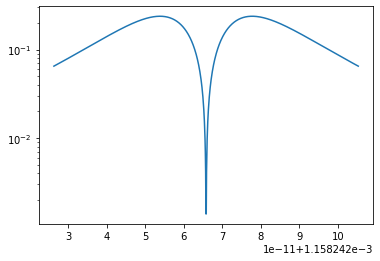

In [4]:
phisAroundInflec = np.linspace(phimin, phimax, 1000)

etaCls = [etaCl_phi([phi, 5e-17]) for phi in phisAroundInflec]

ax = plt.gca()
ax.set_yscale('log')
plt.plot(phisAroundInflec, etaCls)

In [5]:
psimax = bisect(lambda psi: etaCl_psir([phimax, psi]) - 0.1, 0.1 * psirc, 10 * psirc)
psimin = -psimax 
print(psimax) 

1.248173775679675e-16


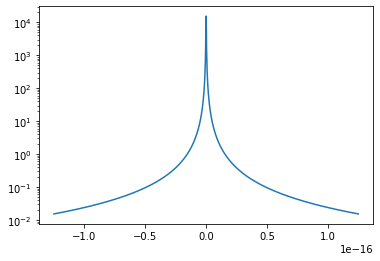

In [6]:
psisAroundInflec = np.linspace(-psimax, psimax, 1000)

etaCls = [etaCl_psir([phimax, psi]) for psi in psisAroundInflec]

ax = plt.gca()
ax.set_yscale('log')
plt.plot(psisAroundInflec, etaCls)

In [7]:
customGrid_phi = np.linspace(phimin, phimax, nGrid)
customGrid_psir = np.linspace(psimin, psimax, nGrid)

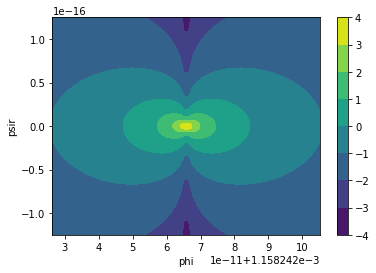

In [8]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psir[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psir, np.log10(etaCls.T))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psir")
plt.show()

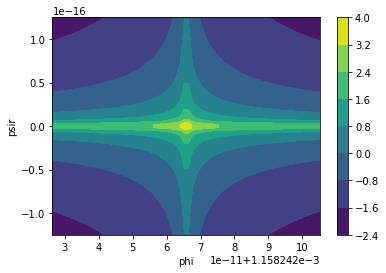

In [9]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psir([customGrid_phi[i], customGrid_psir[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psir, np.log10(etaCls.T))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psir")
plt.show()

In [10]:
# renormPhi = lambda Phi: np.array([(phimax - phimin) * Phi[0] + phimin , (psimax - psimin) * Phi[1] + psimin])

# infPotFuncRenorm = lambda Phi: infPotFunc(renormPhi(Phi))
# infPotentialDerivFuncsRenorm = [lambda Phi: infPotDerivFunc_phi(renormPhi(Phi)) * (phimax - phimin),
#                                 lambda Phi: infPotDerivFunc_psir(renormPhi(Phi)) * (psimax - psimin)]
# infPotentialDeriv2FuncsRenorm = [lambda Phi: infPotDeriv2Func_phi(renormPhi(Phi)) * (phimax - phimin)**2,
#                                  lambda Phi: infPotDeriv2Func_psir(renormPhi(Phi)) * (psimax - psimin)**2]

# customGridRenorm = np.linspace(0, 1, nGrid)

In [11]:
fpFinDiff_NeuNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Neumann0OriFunc"],
    ["Neumann0OriFunc", "Neumann0OriFunc"],
    customGrid=[customGrid_phi, customGrid_psir],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psir_woEnd = customGrid_psir[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psir_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psir_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuNeu, eigVecs_NeuNeu = np.linalg.eig(fpFinDiff_NeuNeu)
eigVecsSort_NeuNeu = eigVecs_NeuNeu.T[np.argsort(eigVals_NeuNeu)]
eigValsSort_NeuNeu = np.sort(eigVals_NeuNeu)

In [12]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuNeu)
np.set_printoptions()

[[3.042551123367740e+01 -1.241762110313332e+01 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-6.208810551566677e+00 1.804459235970077e+01 -6.208810551566639e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -6.208810551566639e+00 1.768268683857539e+01 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  1.728903031411926e+01 -6.208810551566620e+00 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -6.208810551566659e+00 1.765093584682599e+01 -6.208810551566736e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -1.241762110313339e+01 3.003185520035381e+01]]


In [13]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psir],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psir_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

In [14]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

[[1.841897738127434e+01 -6.208810551566639e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-6.208810551566677e+00 1.804459235960966e+01 -6.208810551566639e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -6.208810551566639e+00 1.768268683848802e+01 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  1.728903031403190e+01 -6.208810551566620e+00 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -6.208810551566659e+00 1.765093584673489e+01 -6.208810551566736e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -6.208810551566736e+00 1.802532093044168e+01]]


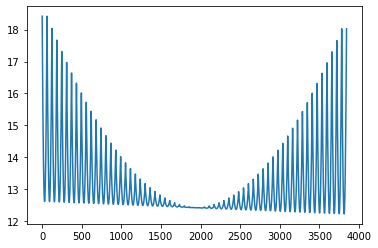

In [15]:
ax = plt.gca()
plt.plot(np.diag(fpFinDiff_DirDir))

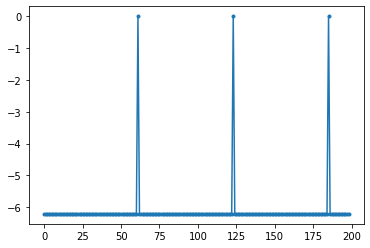

In [16]:
ax = plt.gca()
plt.plot(np.diag(fpFinDiff_DirDir[:200,:200], k=1), marker=".")

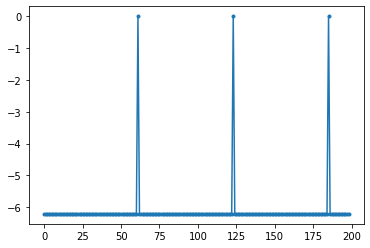

In [17]:
ax = plt.gca()
plt.plot(np.diag(fpFinDiff_DirDir[:200,:200], k=-1), marker=".")

In [18]:
fpFinDiff_DirDir[60:65,60:65]

array([[18.04459238, -6.20881055,  0.        ,  0.        ,  0.        ],
       [-6.20881055, 18.41897738,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , 18.03813902, -6.20881055,  0.        ],
       [ 0.        ,  0.        , -6.20881055, 17.68790136, -6.20881055],
       [ 0.        ,  0.        ,  0.        , -6.20881055, 17.34933832]])

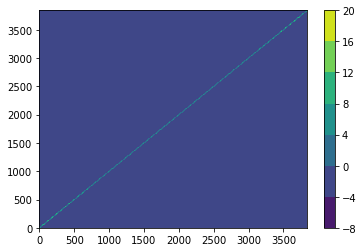

In [19]:
fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(np.arange(62**2), np.arange(62**2), fpFinDiff_DirDir)
fig.colorbar(cntr1, ax=ax1)
plt.show()

<ipython-input-20-2cb570d20588>:2: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(np.abs(fpFinDiff_DirDir[1000,:])), marker=".")


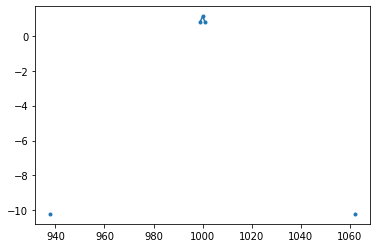

In [20]:
ax = plt.gca()
plt.plot(np.log10(np.abs(fpFinDiff_DirDir[1000,:])), marker=".")

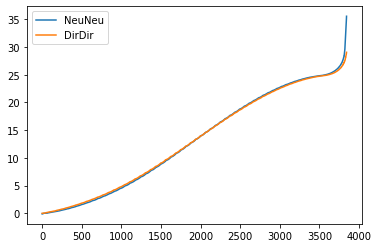

In [21]:
ax = plt.gca()
plt.plot(eigValsSort_NeuNeu, label = "NeuNeu")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

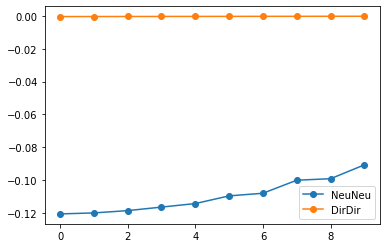

In [22]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_NeuNeu[:10], marker='o', label = "NeuNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [23]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuNeu[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[-1.207399527803557637284370684938e-01
 -1.201353726883061245889194879055e-01
 -1.187279872549962256300659646513e-01
 -1.165813811368748703634068419888e-01
 -1.144244061094130127109735894919e-01
 -1.097403791391365068808028127023e-01
 -1.081423235859095555166931035274e-01
 -1.001781774083333881320001523818e-01
 -9.927276467837914397662757437502e-02
 -9.080546762852671760501976905289e-02]
[-3.907617994478472718024308907303e-04
 -3.655341663692837877834562743118e-04
 -3.411498170960759767668390995965e-04
 -3.176087024205542157055670582366e-04
 -2.949104770739709386120908085616e-04
 -2.730551473788296471326142444980e-04
 -2.520424763621312833940246722619e-04
 -2.318722464442928888912059948169e-04
 -2.125443269170028306579850463365e-04
 -1.940583030086654044675531505249e-04]


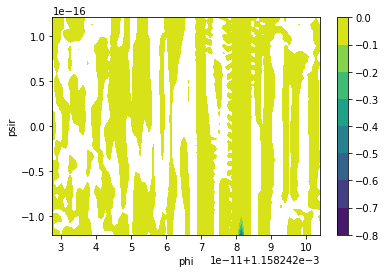

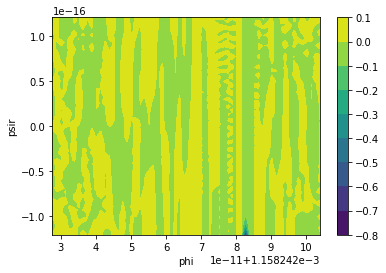

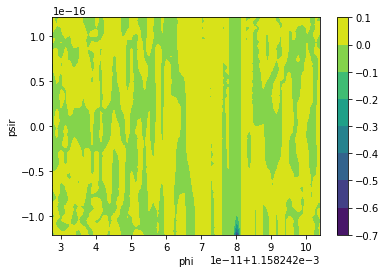

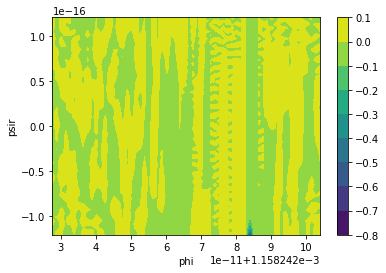

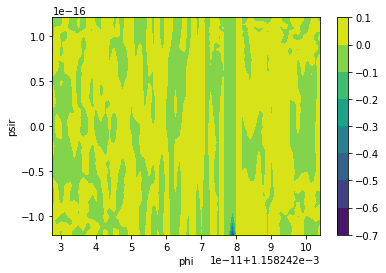

In [24]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psir_woEnd = customGrid_psir[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psir_woEnd, np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

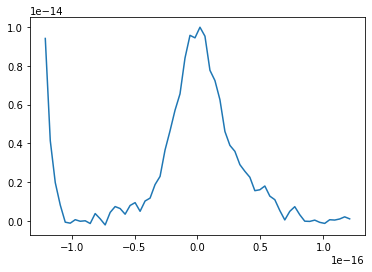

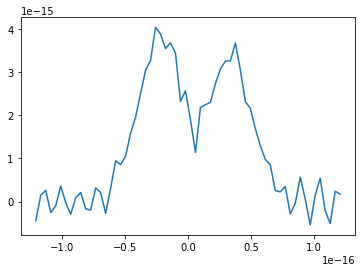

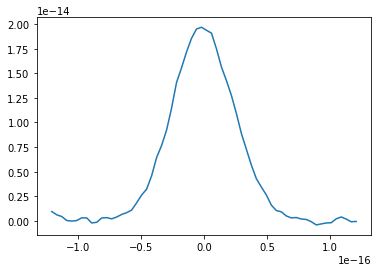

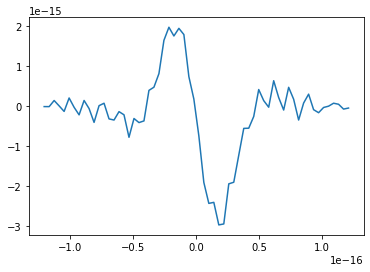

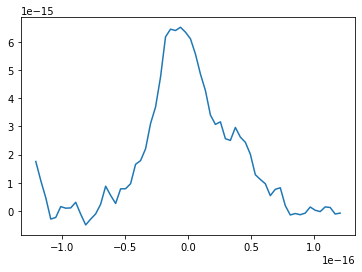

In [25]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir_woEnd, np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[-1,:])
    plt.show()

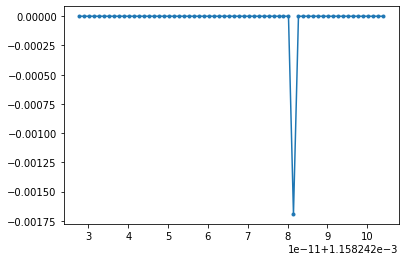

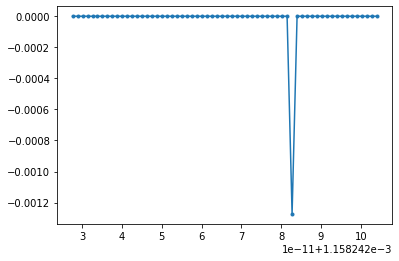

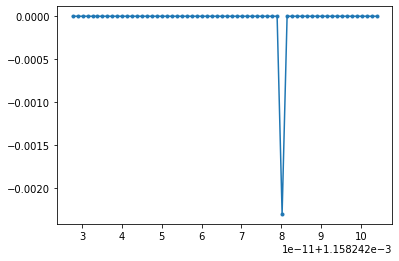

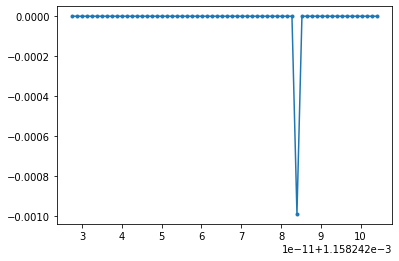

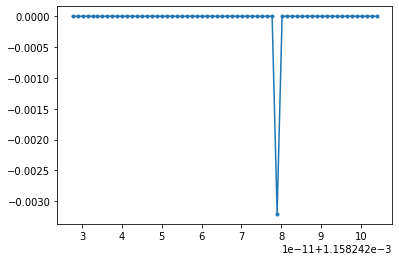

In [26]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    plt.show()

2666 43 -0.7192202301565527


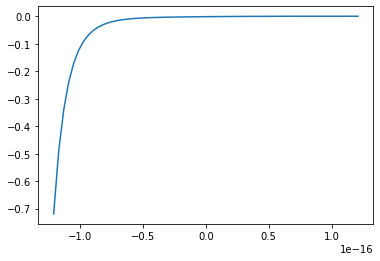

In [33]:
i = np.argmax(np.abs(eigVecsSort_NeuNeu[0]))
print(i, i // (nGrid-2), eigVecsSort_NeuNeu[0][i])

ax = plt.gca()
plt.plot(customGrid_psir_woEnd, np.reshape(eigVecsSort_NeuNeu[0], (nGrid-2, nGrid-2))[i // (nGrid-2),:])
plt.show()

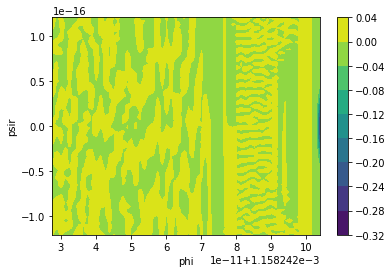

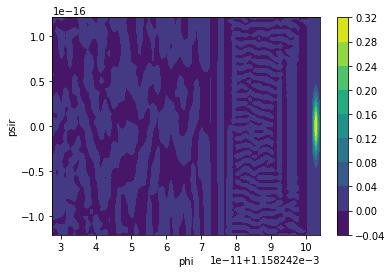

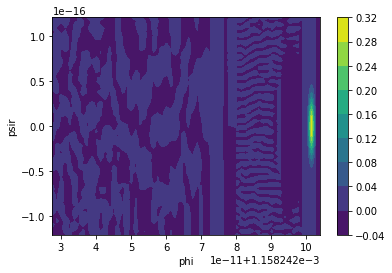

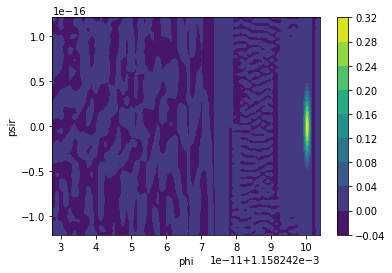

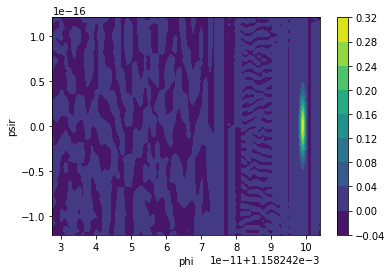

In [27]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psir_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

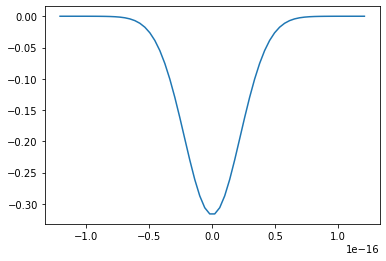

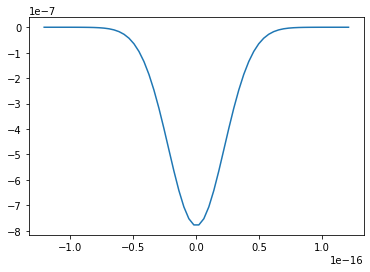

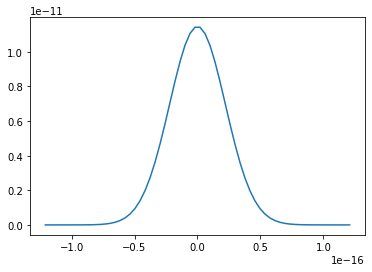

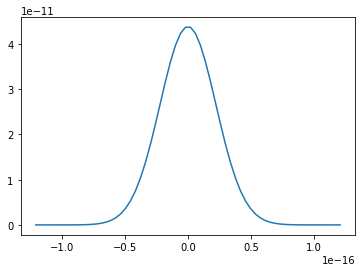

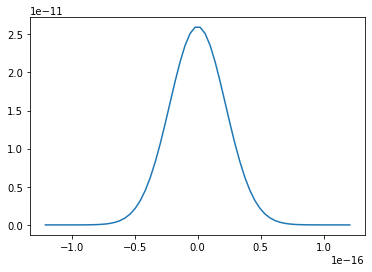

In [28]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[-1,:])
    plt.show()

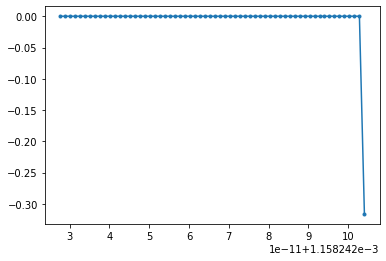

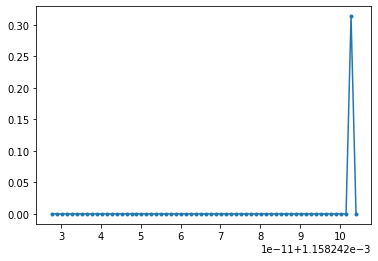

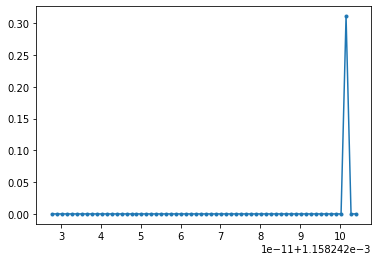

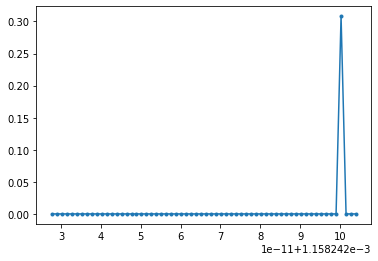

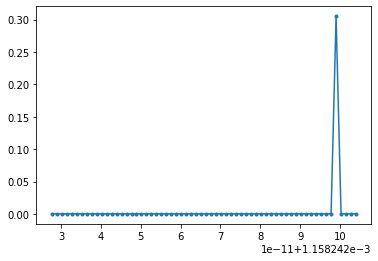

In [29]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    plt.show()

In [36]:
# Neumann-Neumannの解が正しいか確認
# 局在した場所でスライスして1次元の問題として解く
iPhiLocalized_NeuNeuLowest = np.argmax(np.abs(eigVecsSort_NeuNeu[0])) // (nGrid - 2)
phiLocalized_NeuNeuLowest = customGrid_phi[iPhiLocalized_NeuNeuLowest]

infPotFunc_phiLoc = lambda psi: infPotFunc([phiLocalized_NeuNeuLowest, psi])
infPotDerivFunc_psir_phiLoc = lambda psi: infPotDerivFunc_psir([phiLocalized_NeuNeuLowest, psi])
infPotDeriv2Func_psir_phiLoc = lambda psi: infPotDeriv2Func_psir([phiLocalized_NeuNeuLowest, psi])

In [46]:
fpFinDiff_NeuNeu_phiLoc = InfAdjFPFiniteDiff(
    1,
    infPotFunc_phiLoc,
    [infPotDerivFunc_psir_phiLoc],
    [infPotDeriv2Func_psir_phiLoc],
    [nGrid],
    [psimax],
    [psimin],
    ["Neumann0OriFunc"],
    ["Neumann0OriFunc"],
    customGrid=[customGrid_psir],
    set0OutOfInfRegion=False
)

eigVals_NeuNeu_phiLoc, eigVecs_NeuNeu_phiLoc = np.linalg.eig(fpFinDiff_NeuNeu_phiLoc)
eigVecsSort_NeuNeu_phiLoc = eigVecs_NeuNeu_phiLoc.T[np.argsort(eigVals_NeuNeu_phiLoc)]
eigValsSort_NeuNeu_phiLoc = np.sort(eigVals_NeuNeu_phiLoc)

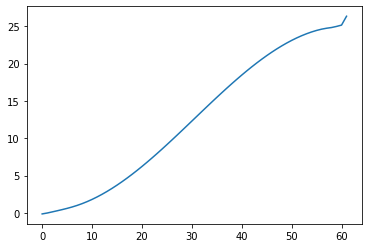

In [47]:
ax = plt.gca()
plt.plot(eigValsSort_NeuNeu_phiLoc)
plt.show()

In [48]:
eigValsSort_NeuNeu_phiLoc

array([-1.18727987e-01,  3.92824990e-05,  1.48880228e-01,  2.99710288e-01,
        4.55950117e-01,  6.22740255e-01,  8.07142628e-01,  1.01637835e+00,
        1.25468038e+00,  1.52320232e+00,  1.82162633e+00,  2.14914699e+00,
        2.50480399e+00,  2.88756721e+00,  3.29635367e+00,  3.73002869e+00,
        4.18740482e+00,  4.66724133e+00,  5.16824482e+00,  5.68907072e+00,
        6.22832552e+00,  6.78456950e+00,  7.35631984e+00,  7.94205413e+00,
        8.54021397e+00,  9.14920887e+00,  9.76742028e+00,  1.03932057e+01,
        1.10249029e+01,  1.16608343e+01,  1.22993113e+01,  1.29386386e+01,
        1.35771187e+01,  1.42130564e+01,  1.48447633e+01,  1.54705618e+01,
        1.60887899e+01,  1.66978056e+01,  1.72959905e+01,  1.78817546e+01,
        1.84535402e+01,  1.90098256e+01,  1.95491287e+01,  2.00700109e+01,
        2.05710799e+01,  2.10509927e+01,  2.15084575e+01,  2.19422354e+01,
        2.23511404e+01,  2.27340376e+01,  2.30898385e+01,  2.34174898e+01,
        2.37159531e+01,  

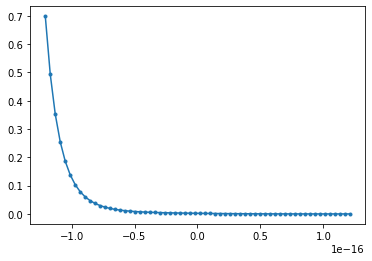

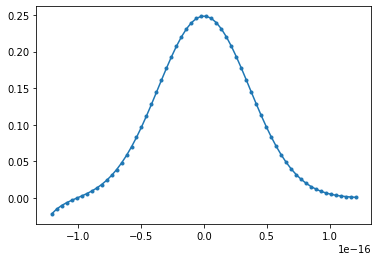

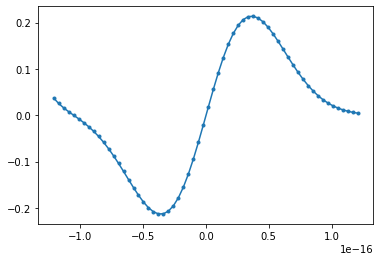

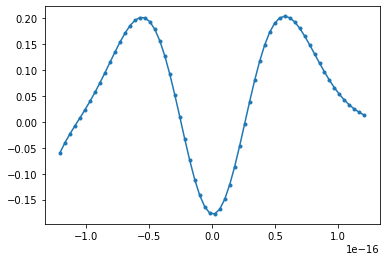

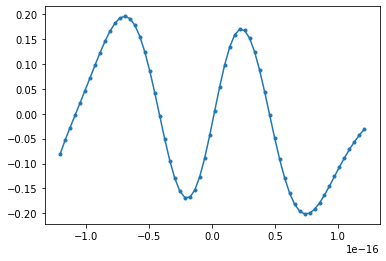

In [49]:
ax = plt.gca()

for iEig in range(5):
    plt.plot(customGrid_psir_woEnd, eigVecsSort_NeuNeu_phiLoc[iEig], marker='.')
    plt.show()

In [50]:
fpFinDiff_NeuNeu_phiLoc[:10,:10]

array([[  8.6415603 , -12.4176211 ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [ -6.20881055,  13.11538928,  -6.20881055,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  -6.20881055,  13.06393857,  -6.20881055,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,  -6.20881055,  13.01426205,
         -6.20881055,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  -6.20881055,
         12.96635968,  -6.20881055,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
         -6.20881055,  12.92023148,  -6.20881055,   0.        ,
          0.        ,   0.        ],
       [  

In [51]:
fpFinDiff_NeuNeu_phiLoc[-10:,-10:]

array([[ 12.75346026,  -6.20881055,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [ -6.20881055,  12.79249182,  -6.20881055,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  -6.20881055,  12.83329754,  -6.20881055,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,  -6.20881055,  12.87587743,
         -6.20881055,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,  -6.20881055,
         12.92023147,  -6.20881055,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
         -6.20881055,  12.96635968,  -6.20881055,   0.        ,
          0.        ,   0.        ],
       [  

・$\Delta \psi \ll \Delta \phi$なので（psiの方がphiよりずっとsmall fieldなので（どっちもsmall fieldだけど））、微分演算子の固有値はほぼpsiのみから決まる

（$|\partial^2 V / \partial \psi^2| \gg |\partial^2 V / \partial \phi^2|$ということ。

離散化行列は、$\Delta \psi \ll \Delta \phi$よりほぼblock-diagonalになり、固有関数はphi方向にlocalizeし、phi方向にスライスしたpsiのみの実質1次元問題になる）

・境界条件の違いが効いているのか？